In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [87]:
# 观察对于一个指数在date这一天的成分股在之前的period里面所占权重的一个变化


def weight_ob(index_name, date, threshold, period):
    date = pd.to_datetime(date)
    data = get_index_weights(index_name, date).sort_values(by='weight', ascending=False) # 按权重大小排序

    i = 0
    total = 0
    code_lis = []
    weight_lis = []
    name_lis = []
    
    # 选择累计权重，threshold=40就是选择date这天权重最大的且累计权重超过的40%的这部分股票，=100则选择了当天指数的所有成分股
    while total <= threshold:
        code_lis.append(data.index[i])
        name_lis.append(data['display_name'].iloc[i])
        weight_lis.append(data['weight'].iloc[i])
        total += data['weight'].iloc[i]
        i += 1

    total_weight = []
    start = date - datetime.timedelta(days=period)
    date_lis = get_price(index_name, start_date=start, end_date=date).index.tolist() # 交易日时间列表

    for date in date_lis:
        total = get_index_weights(index_name, date).loc[code_lis, 'weight'].sum() # code_lis中的股票在这一天的权重总和
        total_weight.append(total)

    df = pd.DataFrame(total_weight, index=date_lis, columns=['Total_weight'])
    df.plot(figsize=(15,8))
    return df

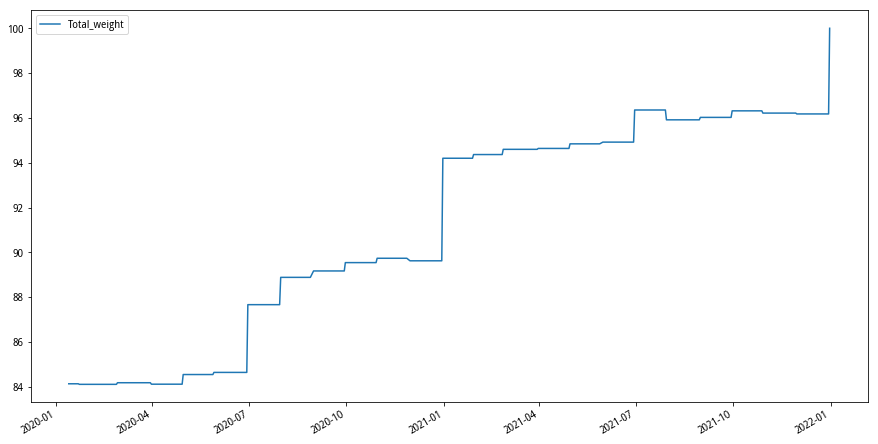

In [88]:
df = weight_ob("000016.XSHG", date="2022-01-01", threshold=100, period=720)